In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBRegressor

In [2]:
seed = 42

In [3]:
data = pd.read_csv("Elek_price_onsh.csv")

In [4]:
data.head()

,Unnamed: 0,year_mon_day,hour,wind_dir_avg_10,wind_speed_h_avg,wind_speed_avg_10,air_pressure,humidity,full_datetime,capacity,...,emission,emissionfactor,correct_days,date,month,week_number,max_capacity,log_volume,ratio_VC,prijs_excl_belastingen
0,2017-01-01 00:00:00,20170101,0,207.708194,49.666667,49.666667,10234.526316,98.076923,2017-01-01-01,679334,...,0,0,2017-01-01-01,2017-01-01,2017-01,1,861301.051331,13.428870,0.788730,0.0420
1,2017-01-01 01:00:00,20170101,1,205.010321,50.000000,51.333333,10227.789474,98.153846,2017-01-01-02,677462,...,0,0,2017-01-01-02,2017-01-01,2017-01,1,861299.514778,13.426110,0.786558,0.0499
2,2017-01-01 02:00:00,20170101,2,202.701006,51.666667,51.000000,10219.473684,98.230769,2017-01-01-03,653746,...,0,0,2017-01-01-03,2017-01-01,2017-01,1,861297.084050,13.390476,0.759025,0.0520
3,2017-01-01 03:00:00,20170101,3,201.007553,52.333333,54.666667,10211.368421,98.038462,2017-01-01-04,705882,...,0,0,2017-01-01-04,2017-01-01,2017-01,1,861302.267903,13.467205,0.819552,0.0410
4,2017-01-01 04:00:00,20170101,4,200.325015,52.666667,53.333333,10203.526316,97.461538,2017-01-01-05,716738,...,0,0,2017-01-01-05,2017-01-01,2017-01,1,861300.347955,13.482467,0.832158,0.0390


In [5]:
len(data)

70128

In [6]:
X = data.drop(["volume", "capacity",  #capacity & volume are the same
                    "emission", "emissionfactor", "log_volume"], #are always 0 and can be ignored
                      axis=1)

# our target variable
y = data["volume"]
y_log = data["log_volume"]
X_train = X[X["date"] < "2024-01-01"]
X_test = X[X["date"] >= "2024-01-01"]

# Label
y_train = y[:X_train.shape[0]] #list slice: from beginning to end of X-train
y_test = y[X_train.shape[0]:] #list slice: from end of X-train to the end of the data
y_train_log = y_log[:X_train.shape[0]]
y_test_log = y_log[X_train.shape[0]:]

In [7]:
print(X_train.shape)
print(y_train.shape)
print(y_test.shape)
print(X_test.shape)
print(y_train_log.shape)
print(y_test_log.shape)

(61344, 17)
(61344,)
(8784,)
(8784, 17)
(61344,)
(8784,)


In [8]:
# subset dataframe to only contain the features we are interested in
numeric_features = ["wind_dir_avg_10", "wind_speed_h_avg", "wind_speed_avg_10", "air_pressure", "humidity", "percentage", 
                    "max_capacity", 
                    "prijs_excl_belastingen"]
X_train_p = X_train.loc[:, numeric_features]
X_test_p = X_test.loc[:, numeric_features]

# Define the preprocessor
preprocessor = ColumnTransformer([
    ("scaled_num", StandardScaler(), numeric_features)
])

# Transform the data with the scaler
X_train_norm_p = preprocessor.fit_transform(X_train_p)
X_test_norm_p = preprocessor.fit_transform(X_test_p)
X_train_p = pd.DataFrame(X_train_norm_p, columns=X_train_p.columns.values, index=X_train_p.index.values)
X_test_p = pd.DataFrame(X_test_norm_p, columns = X_test_p.columns.values, index=X_test_p.index.values)


In [9]:
print(X_train_p.shape)
print(y_train.shape)
print(y_test.shape)
print(X_test_p.shape)
print(y_train_log.shape)
print(y_test_log.shape)

(61344, 8)
(61344,)
(8784,)
(8784, 8)
(61344,)
(8784,)


In [10]:
param_grid = {
    'max_depth': [3, 5],
    'n_estimators': [50]
}
model = XGBRegressor()
grid = GridSearchCV(model, param_grid=param_grid, cv=3)
grid.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, max_bin=None,
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=None, ...),
             param_grid={'max_depth': [3, 5], 'n_estimators': [50]})

In [10]:
param_grid = {
    'max_depth': [5, 7],  
    'min_child_weight': [1, 2, 3],  
    'learning_rate': [0.01, 0.05],  
    'n_estimators': [50, 100, 150],  
    'subsample': [0.75, 0.9],  
    'colsample_bytree': [0.75, 0.9]
}

XGB = XGBRegressor(random_state = 42)
cv_XGB_p = GridSearchCV(estimator=XGB, param_grid=param_grid, cv=5) #Here we perform a grid search with 5-fold cross validation
cv_XGB_p.fit(X_train_p, y_train) # Fit the model to the training set - this will perform the grid search and find the model with the best hyper-parameters

# Mean cross-validated score of the best_estimator
print("Mean cross-validated score of the best_estimator:", cv_XGB_p.best_score_)

# Print the best parameters
print("Best parameters:", cv_XGB_p.best_params_)

# Refit the model with the best parameters on the entire training set
XGB_model_p = cv_XGB_p.best_estimator_
XGB_pred_p = XGB_model_p.predict(X_test_p)

#Calculating the accuracy
print("Best XGB Classifier")
print("Test Set MSE: ", mean_squared_error(y_test, XGB_pred_p))

Mean cross-validated score of the best_estimator: 0.937464720282388
Best parameters: {'colsample_bytree': 0.75, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 150, 'subsample': 0.9}
Best XGB Classifier
Test Set MSE:  2076134550652.8462


# Logged version

In [11]:
param_grid = {
    'max_depth': [5, 7],  
    'min_child_weight': [1, 2, 3],  
    'learning_rate': [0.01, 0.05],  
    'n_estimators': [50, 100, 150],  
    'subsample': [0.75, 0.9],  
    'colsample_bytree': [0.75, 0.9]
}

XGB = XGBRegressor(random_state = 42)
cv_XGB_log_p = GridSearchCV(estimator=XGB, param_grid=param_grid, cv=5) #Here we perform a grid search with 5-fold cross validation
cv_XGB_log_p.fit(X_train_p, y_train_log) # Fit the model to the training set - this will perform the grid search and find the model with the best hyper-parameters

# Mean cross-validated score of the best_estimator
print("Mean cross-validated score of the best_estimator:", cv_XGB_log_p.best_score_)

# Print the best parameters
print("Best parameters:", cv_XGB_log_p.best_params_)

# Refit the model with the best parameters on the entire training set
XGB_model_log_p = cv_XGB_log_p.best_estimator_
XGB_pred_log_p = XGB_model_log_p.predict(X_test_p)

#Calculating the accuracy
print("Best XGB Classifier")
print("Test Set MSE: ", mean_squared_error(y_test_log, XGB_pred_log_p))


Mean cross-validated score of the best_estimator: 0.9956458025548865
Best parameters: {'colsample_bytree': 0.75, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 2, 'n_estimators': 150, 'subsample': 0.9}
Best XGB Classifier
Test Set MSE:  5.34425857473131


In [12]:
x_axis_train = data["date"][:len(y_train_log)]
x_axis_test = data["date"][len(y_train_log):]
x_axis_train[0:5]
print(len(x_axis_train))
print(len(x_axis_test))

61344
8784


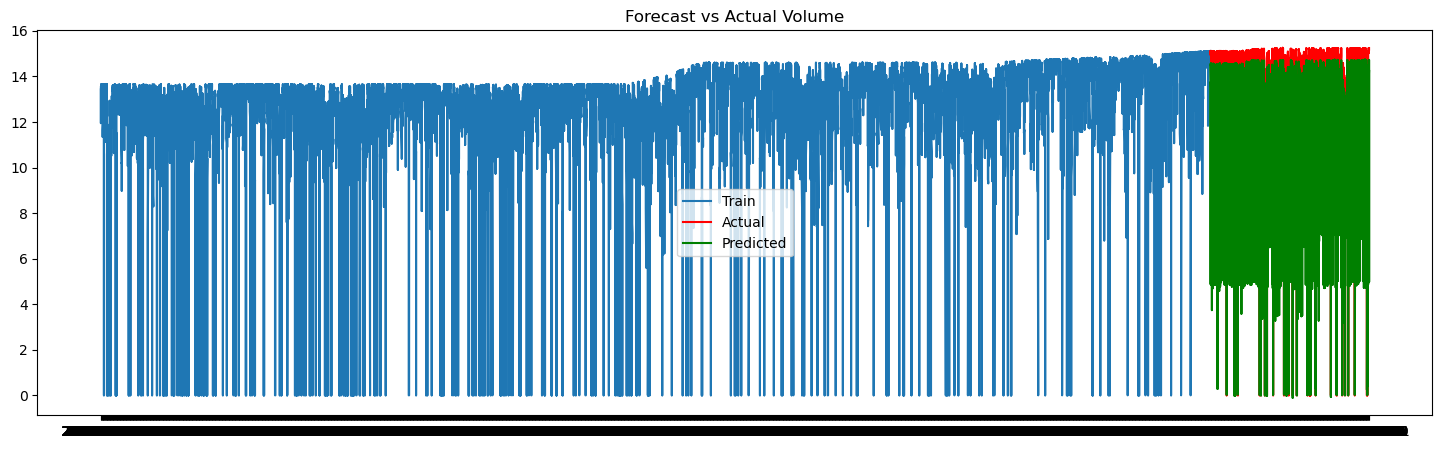

In [13]:
plt.figure(figsize=(18,5))
plt.plot(x_axis_train, y_train_log, label="Train")
plt.plot(x_axis_test, y_test_log, label="Actual", color='red')
plt.plot(x_axis_test, XGB_pred_log_p, label="Predicted", color='green')
plt.legend()
plt.title("Forecast vs Actual Volume")
plt.show()

# Monthly

In [10]:
# Convert hourly data to monthly data
db_monthly = data.groupby('month').mean(numeric_only=True)
# Split into train and test set
train_db = db_monthly[db_monthly.index <= '2024-06']
test_db = db_monthly[db_monthly.index > '2024-06']

X_month = db_monthly.drop(["volume", "capacity",  #capacity & volume are the same
                    "emission", "emissionfactor", "log_volume", "ratio_VC"], #are always 0 and can be ignored
                      axis=1)

# our target variable
y_month_log = db_monthly["log_volume"]
y_month = db_monthly["volume"]

# Features
X_train_month = X_month[X_month.index <= '2024-06']
X_test_month = X_month[(X_month.index > '2024-06')]


# Label log
y_train_month_log = y_month_log[:X_train_month.shape[0]] #list slice: from beginning to end of X-train
y_test_month_log = y_month_log[X_train_month.shape[0]:] #list slice: from end of X-train to the end of the data

# Label
y_train_month = y_month[:X_train_month.shape[0]] #list slice: from beginning to end of X-train
y_test_month = y_month[X_train_month.shape[0]:] #list slice: from end of X-train to the end of the data



In [11]:
print(X_train_month.shape)
print(X_test_month.shape)
print(y_train_month.shape)
print(y_test_month.shape)
print(y_train_month_log.shape)
print(y_test_month_log.shape)

(90, 11)
(6, 11)
(90,)
(6,)
(90,)
(6,)


In [12]:
print(X_train_month["prijs_excl_belastingen"].dtype)

float64


In [13]:
# subset dataframe to only contain the features we are interested in
numeric_features = ["wind_dir_avg_10", "wind_speed_h_avg", "wind_speed_avg_10", "air_pressure", "humidity", "percentage", 
                    "max_capacity", "prijs_excl_belastingen"]
X_train_month_p = X_train_month.loc[:, numeric_features]
X_test_month_p = X_test_month.loc[:, numeric_features]

# Define the preprocessor
preprocessor = ColumnTransformer([
    ("scaled_num", StandardScaler(), numeric_features)
])


# Transform the data with the scaler
X_train_norm_month_p = preprocessor.fit_transform(X_train_month_p)
X_test_norm_month_p = preprocessor.fit_transform(X_test_month_p)


In [14]:
#add feature names back 
X_train_month = pd.DataFrame(X_train_norm_month_p, columns=X_train_month_p.columns.values, index=X_train_month_p.index.values)

X_test_month = pd.DataFrame(X_test_norm_month_p, columns = X_test_month_p.columns.values, index=X_test_month_p.index.values)

X_train_month_p.head()

,wind_dir_avg_10,wind_speed_h_avg,wind_speed_avg_10,air_pressure,humidity,percentage,max_capacity,prijs_excl_belastingen
month,,,,,,,,
2017-01,185.731777,36.941244,36.996098,10228.397969,87.256987,0.465300,861300.046159,0.048947
2017-02,164.843658,50.570396,50.605399,10151.514753,85.539303,0.673527,861301.737837,0.037910
2017-03,188.493760,45.367780,45.458787,10155.116381,78.163972,0.479421,861299.766603,0.035407
2017-04,236.862021,38.027719,38.274926,10211.061356,74.574933,0.443371,861299.510125,0.036176
2017-05,167.468880,36.510271,36.609297,10170.346032,73.232587,0.370283,861299.841886,0.035614


In [15]:
print(X_train_month_p.shape)
print(X_test_month_p.shape)
print(y_train_month.shape)
print(y_test_month.shape)
print(y_train_month_log.shape)
print(y_test_month_log.shape)

(90, 8)
(6, 8)
(90,)
(6,)
(90,)
(6,)


In [16]:
param_grid = {
    'max_depth': [5, 7],  
    'min_child_weight': [1, 2, 3],  
    'learning_rate': [0.01, 0.05],  
    'n_estimators': [50, 100, 150],  
    'subsample': [0.75, 0.9],  
    'colsample_bytree': [0.75, 0.9]
}

XGB = XGBRegressor(random_state = 15)
cv_XGB_month_log_p = GridSearchCV(estimator=XGB, param_grid=param_grid, cv=5) #Here we perform a grid search with 5-fold cross validation
cv_XGB_month_log_p.fit(X_train_month_p, y_train_month_log) # Fit the model to the training set - this will perform the grid search and find the model with the best hyper-parameters

# Mean cross-validated score of the best_estimator
print("Mean cross-validated score of the best_estimator:", cv_XGB_month_log_p.best_score_)

# Print the best parameters
print("Best parameters:", cv_XGB_month_log_p.best_params_)

# Refit the model with the best parameters on the entire training set
XGB_model_month_log_p = cv_XGB_month_log_p.best_estimator_
XGB_pred_month_log_p = XGB_model_month_log_p.predict(X_test_month_p)

#Calculating the accuracy
print("Best XGB Classifier")
print("Test Set MSE: ", mean_squared_error(y_test_month_log, XGB_pred_month_log_p))

Mean cross-validated score of the best_estimator: 0.5464168419025394
Best parameters: {'colsample_bytree': 0.75, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 150, 'subsample': 0.9}
Best XGB Classifier
Test Set MSE:  0.04189113125219235


In [19]:
x_axis_train_m = db_monthly["year_mon_day"][:len(y_train_month)]
x_axis_test_m = db_monthly["year_mon_day"][len(y_train_month):]
print(len(x_axis_train_m))
print(len(x_axis_test_m))

90
6


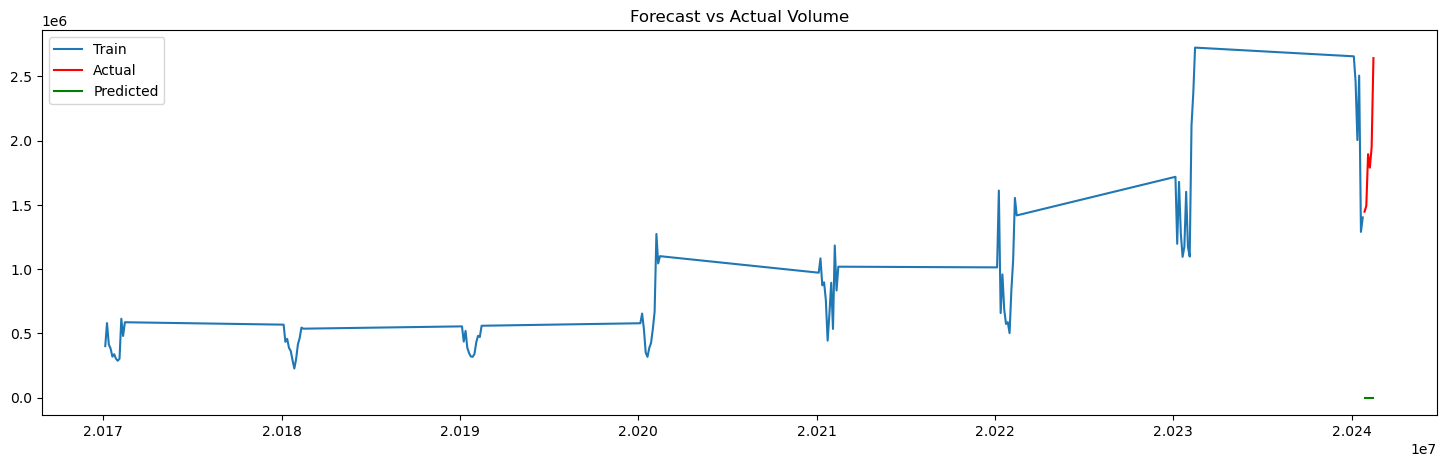

In [20]:
plt.figure(figsize=(18,5))
plt.plot(x_axis_train_m, y_train_month, label="Train")
plt.plot(x_axis_test_m, y_test_month, label="Actual", color='red')
plt.plot(x_axis_test_m, XGB_pred_month_log_p, label="Predicted", color='green')
plt.legend()
plt.title("Forecast vs Actual Volume")
plt.show()

In [17]:
param_grid = {
    'max_depth': [5, 7],  
    'min_child_weight': [1, 2, 3],  
    'learning_rate': [0.01, 0.05],  
    'n_estimators': [50, 100, 150],  
    'subsample': [0.75, 0.9],  
    'colsample_bytree': [0.75, 0.9]
}

XGB = XGBRegressor(random_state = 15)
cv_XGB_month_p = GridSearchCV(estimator=XGB, param_grid=param_grid, cv=5) #Here we perform a grid search with 5-fold cross validation
cv_XGB_month_p.fit(X_train_month_p, y_train_month) # Fit the model to the training set - this will perform the grid search and find the model with the best hyper-parameters

# Mean cross-validated score of the best_estimator
print("Mean cross-validated score of the best_estimator:", cv_XGB_month_p.best_score_)

# Print the best parameters
print("Best parameters:", cv_XGB_month_p.best_params_)

# Refit the model with the best parameters on the entire training set
XGB_model_month_p = cv_XGB_month_p.best_estimator_
XGB_pred_month_p = XGB_model_month_p.predict(X_test_month_p)

#Calculating the accuracy
print("Best XGB Classifier")
print("Test Set MSE: ", mean_squared_error(y_test_month, XGB_pred_month_p))


Mean cross-validated score of the best_estimator: 0.5280716075793456
Best parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 7, 'min_child_weight': 2, 'n_estimators': 150, 'subsample': 0.9}
Best XGB Classifier
Test Set MSE:  49381511924.37103


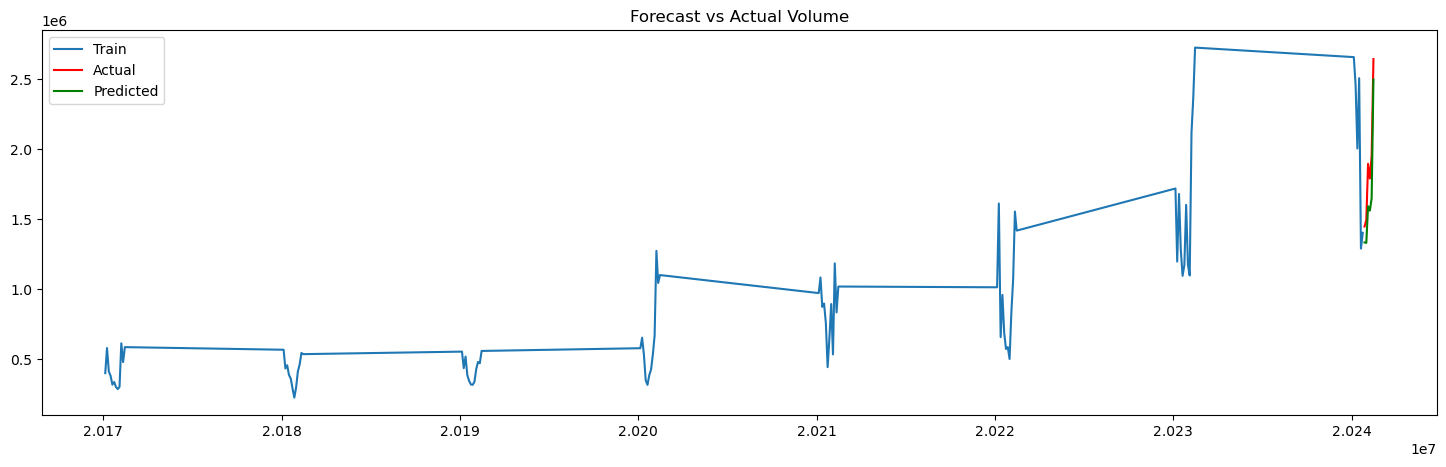

In [21]:
plt.figure(figsize=(18,5))
plt.plot(x_axis_train_m, y_train_month, label="Train")
plt.plot(x_axis_test_m, y_test_month, label="Actual", color='red')
plt.plot(x_axis_test_m, XGB_pred_month_p, label="Predicted", color='green')
plt.legend()
plt.title("Forecast vs Actual Volume")
plt.show()

# Weekly

In [22]:
# Convert hourly data to weekly data
db_weekly = data.groupby('week_number').mean(numeric_only=True)

X_week = db_weekly.drop(["volume", "capacity",  #capacity & volume are the same
                    "emission", "emissionfactor", "log_volume", "ratio_VC"], #are always 0 and can be ignored
                      axis=1)


# our target variable
y_week = db_weekly["volume"]
y_week_log = db_weekly["log_volume"]

# Features
X_train_week = X_week[X_week.index <= 406]
X_test_week = X_week[(X_week.index > 406)]

# Label
y_train_week = y_week[:X_train_week.shape[0]] #list slice: from beginning to end of X-train
y_test_week = y_week[X_train_week.shape[0]:] #list slice: from end of X-train to the end of the data

# Label Log
y_train_week_log = y_week_log[:X_train_week.shape[0]] #list slice: from beginning to end of X-train
y_test_week_log = y_week_log[X_train_week.shape[0]:] #list slice: from end of X-train to the end of the data

In [23]:
print(X_train_week.shape)
print(X_test_week.shape)
print(y_train_week.shape)
print(y_test_week.shape)
print(y_train_week_log.shape)
print(y_test_week_log.shape)

(406, 10)
(12, 10)
(406,)
(12,)
(406,)
(12,)


In [24]:
# subset dataframe to only contain the features we are interested in
numeric_features = ["wind_dir_avg_10", "wind_speed_h_avg", "wind_speed_avg_10", "air_pressure", "humidity", "percentage", 
                    "max_capacity", "prijs_excl_belastingen"]
X_train_week_p = X_train_week.loc[:, numeric_features]
X_test_week_p = X_test_week.loc[:, numeric_features]

# Define the preprocessor
preprocessor = ColumnTransformer([
    ("scaled_num", StandardScaler(), numeric_features)
])


# Transform the data with the scaler
X_train_norm_week_p = preprocessor.fit_transform(X_train_week_p)
X_test_norm_week_p = preprocessor.fit_transform(X_test_week_p)

In [69]:
#add feature names back 
X_train_week_p = pd.DataFrame(X_train_norm_week_p, columns=X_train_week_p.columns.values, index=X_train_week_p.index.values)

X_test_week_p = pd.DataFrame(X_test_norm_week_p, columns = X_test_week_p.columns.values, index=X_test_week_p.index.values)

X_train_week_p.head()

,wind_dir_avg_10,wind_speed_h_avg,wind_speed_avg_10,air_pressure,humidity,percentage,max_capacity,prijs_excl_belastingen
1,0.964307,0.791946,0.793976,1.316377,0.003672,1.183927,-0.965738,-0.610106
2,1.276994,1.146825,1.148706,-0.582877,0.539061,0.919688,-0.965738,-0.587360
3,-1.000973,-1.948013,-1.950196,2.286471,0.994825,-1.434145,-0.965729,-0.365025
4,-0.338505,-1.304255,-1.299511,1.138929,0.962738,-0.665767,-0.965731,-0.384954
5,-0.968562,-0.336506,-0.348301,-0.765821,1.449451,0.530952,-0.965738,-0.525912


In [25]:
print(X_train_week_p.shape)
print(X_test_week_p.shape)
print(y_train_week.shape)
print(y_test_week.shape)
print(y_train_week_log.shape)
print(y_test_week_log.shape)

(406, 8)
(12, 8)
(406,)
(12,)
(406,)
(12,)


In [26]:
param_grid = {
    'max_depth': [5, 7],  
    'min_child_weight': [1, 2, 3],  
    'learning_rate': [0.01, 0.05],  
    'n_estimators': [50, 100, 150],  
    'subsample': [0.75, 0.9],  
    'colsample_bytree': [0.75, 0.9]
}

XGB = XGBRegressor(random_state = 15)
cv_XGB_week_p = GridSearchCV(estimator=XGB, param_grid=param_grid, cv=5) #Here we perform a grid search with 5-fold cross validation
cv_XGB_week_p.fit(X_train_week_p, y_train_week) # Fit the model to the training set - this will perform the grid search and find the model with the best hyper-parameters

# Mean cross-validated score of the best_estimator
print("Mean cross-validated score of the best_estimator:", cv_XGB_week_p.best_score_)

# Print the best parameters
print("Best parameters:", cv_XGB_week_p.best_params_)

# Refit the model with the best parameters on the entire training set
XGB_model_week_p = cv_XGB_week_p.best_estimator_
XGB_pred_week_p = XGB_model_week_p.predict(X_test_week_p)

#Calculating the accuracy
print("Best XGB Classifier")
print("Test Set MSE: ", mean_squared_error(y_test_week, XGB_pred_week_p))


Mean cross-validated score of the best_estimator: 0.9000668697768036
Best parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 2, 'n_estimators': 150, 'subsample': 0.75}
Best XGB Classifier
Test Set MSE:  57644785074.89319


In [27]:
param_grid = {
    'max_depth': [5, 7],  
    'min_child_weight': [1, 2, 3],  
    'learning_rate': [0.01, 0.05],  
    'n_estimators': [50, 100, 150],  
    'subsample': [0.75, 0.9],  
    'colsample_bytree': [0.75, 0.9]
}

XGB = XGBRegressor(random_state = 15)
cv_XGB_week_log_p = GridSearchCV(estimator=XGB, param_grid=param_grid, cv=5) #Here we perform a grid search with 5-fold cross validation
cv_XGB_week_log_p.fit(X_train_week_p, y_train_week_log) # Fit the model to the training set - this will perform the grid search and find the model with the best hyper-parameters

# Mean cross-validated score of the best_estimator
print("Mean cross-validated score of the best_estimator:", cv_XGB_week_log_p.best_score_)

# Print the best parameters
print("Best parameters:", cv_XGB_week_log_p.best_params_)

# Refit the model with the best parameters on the entire training set
XGB_model_week_log_p = cv_XGB_week_log_p.best_estimator_
XGB_pred_week_log_p = XGB_model_week_log_p.predict(X_test_week_p)

#Calculating the accuracy
print("Best XGB Classifier")
print("Test Set MSE: ", mean_squared_error(y_test_week_log, XGB_pred_week_log_p))

Mean cross-validated score of the best_estimator: 0.7254989544061626
Best parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 100, 'subsample': 0.75}
Best XGB Classifier
Test Set MSE:  0.26672512797571235


In [28]:
x_axis_train_w = db_weekly["year_mon_day"][:len(y_train_week)]
x_axis_test_w = db_weekly["year_mon_day"][len(y_train_week):]
print(len(x_axis_train_w))
print(len(x_axis_test_w))

406
12


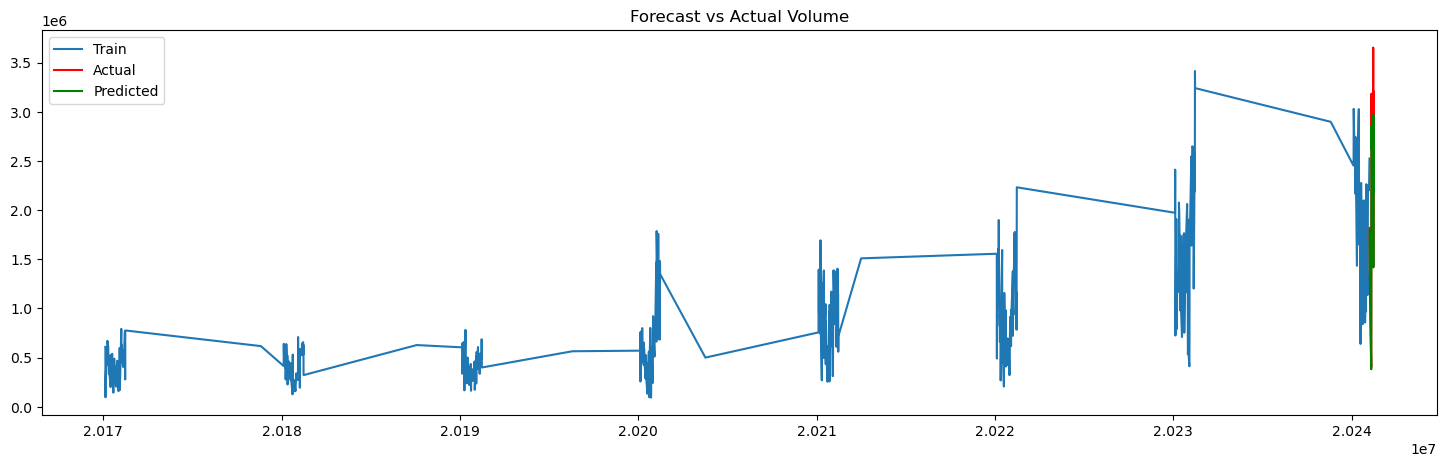

In [29]:
plt.figure(figsize=(18,5))
plt.plot(x_axis_train_w, y_train_week, label="Train")
plt.plot(x_axis_test_w, y_test_week, label="Actual", color='red')
plt.plot(x_axis_test_w, XGB_pred_week_p, label="Predicted", color='green')
plt.legend()
plt.title("Forecast vs Actual Volume")
plt.show()

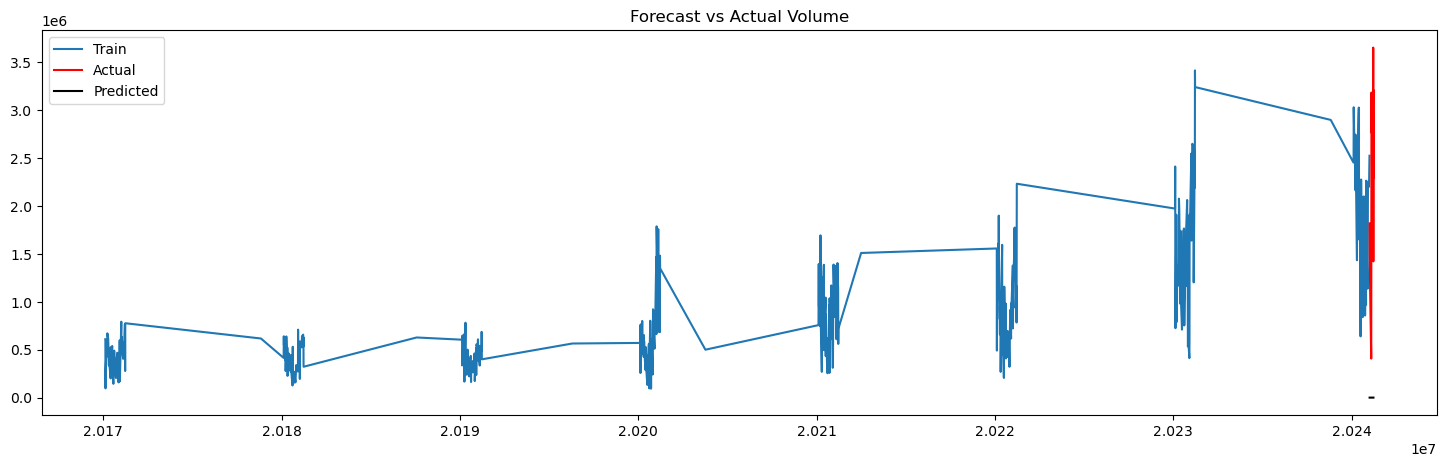

In [32]:
plt.figure(figsize=(18,5))
plt.plot(x_axis_train_w, y_train_week, label="Train")
plt.plot(x_axis_test_w, y_test_week, label="Actual", color='red')
plt.plot(x_axis_test_w, XGB_pred_week_log_p, label="Predicted", color='black')
plt.legend()
plt.title("Forecast vs Actual Volume")
plt.show()

In [31]:
XGB_pred_week_log_p[0:5]

array([13.820488, 13.533184, 12.57486 , 11.57271 , 13.687227],
      dtype=float32)

In [33]:
y_test_week_log[0:5]

week_number
407    13.170476
408    13.720689
409    12.947995
410    11.929705
411    13.763364
Name: log_volume, dtype: float64

# Daily

In [34]:
data['date2'] = pd.to_datetime(data['date'], format='ISO8601')
db_daily = data.groupby('date2').mean(numeric_only=True)
# Split into train and test set
db_daily.index = pd.to_datetime(db_daily.index)

X_day = db_daily.drop(["volume", "capacity",  #capacity & volume are the same
                    "emission", "emissionfactor", "log_volume", "ratio_VC"], #are always 0 and can be ignored
                      axis=1)

#our targer variable
y_day = db_daily["volume"]
y_day_log = db_daily["log_volume"]

# Features
X_train_day = X_day[X_day.index <= '2024-11-01']
X_test_day = X_day[X_day.index > '2024-11-01']

# Label
y_train_day = y_day[:X_train_day.shape[0]] #list slice: from beginning to end of X-train
y_test_day = y_day[X_train_day.shape[0]:] #list slice: from end of X-train to the end of the data

# Label log
y_train_day_log = y_day_log[:X_train_day.shape[0]] #list slice: from beginning to end of X-train
y_test_day_log = y_day_log[X_train_day.shape[0]:] #list slice: from end of X-train to the end of the data

In [35]:
print(X_train_day.shape)
print(X_test_day.shape)
print(y_train_day.shape)
print(y_test_day.shape)
print(y_train_day_log.shape)
print(y_test_day_log.shape)

(2862, 11)
(60, 11)
(2862,)
(60,)
(2862,)
(60,)


In [36]:
# subset dataframe to only contain the features we are interested in
numeric_features = ["wind_dir_avg_10", "wind_speed_h_avg", "wind_speed_avg_10", "air_pressure", "humidity", "percentage", 
                    "max_capacity", "prijs_excl_belastingen"]
X_train_day_p = X_train_day.loc[:, numeric_features]
X_test_day_p = X_test_day.loc[:, numeric_features]

# Define the preprocessor
preprocessor = ColumnTransformer([
    ("scaled_num", StandardScaler(), numeric_features)
])

# Transform the data with the scaler
X_train_norm_day_p = preprocessor.fit_transform(X_train_day_p)
X_test_norm_day_p = preprocessor.fit_transform(X_test_day_p)

In [37]:
#add feature names back 
X_train_day_p = pd.DataFrame(X_train_norm_day_p, columns=X_train_day_p.columns.values, index=X_train_day_p.index.values)
X_test_day_p = pd.DataFrame(X_test_norm_day_p, columns = X_test_day_p.columns.values, index=X_test_day_p.index.values)
X_train_day_p.head()

,wind_dir_avg_10,wind_speed_h_avg,wind_speed_avg_10,air_pressure,humidity,percentage,max_capacity,prijs_excl_belastingen
2017-01-01,0.288762,0.495793,0.496660,0.357645,1.639381,0.378449,-1.099395,-0.499735
2017-01-02,1.309003,-0.539869,-0.538402,0.809815,0.846960,1.003264,-1.099396,-0.429690
2017-01-03,0.827166,1.183119,1.222583,0.662124,0.866448,1.078344,-1.099396,-0.581768
2017-01-04,1.589490,1.388179,1.348183,0.203361,0.060603,1.222940,-1.099396,-0.619609
2017-01-05,-0.665349,-0.765440,-0.794530,1.758904,0.112978,-0.514666,-1.099395,-0.586238


In [38]:
print(X_train_day_p.shape)
print(X_test_day_p.shape)
print(y_train_day.shape)
print(y_test_day.shape)
print(y_train_day_log.shape)
print(y_test_day_log.shape)

(2862, 8)
(60, 8)
(2862,)
(60,)
(2862,)
(60,)


In [39]:
param_grid = {
    'max_depth': [5, 7],  
    'min_child_weight': [1, 2, 3],  
    'learning_rate': [0.01, 0.05],  
    'n_estimators': [50, 100, 150],  
    'subsample': [0.75, 0.9],  
    'colsample_bytree': [0.75, 0.9]
}

XGB = XGBRegressor(random_state = 15)
cv_XGB_day_p = GridSearchCV(estimator=XGB, param_grid=param_grid, cv=5) #Here we perform a grid search with 5-fold cross validation
cv_XGB_day_p.fit(X_train_day_p, y_train_day) # Fit the model to the training set - this will perform the grid search and find the model with the best hyper-parameters

# Mean cross-validated score of the best_estimator
print("Mean cross-validated score of the best_estimator:", cv_XGB_day_p.best_score_)

# Print the best parameters
print("Best parameters:", cv_XGB_day_p.best_params_)

# Refit the model with the best parameters on the entire training set
XGB_model_day_p = cv_XGB_day_p.best_estimator_
XGB_pred_day_p = XGB_model_day_p.predict(X_test_day_p)

#Calculating the accuracy
print("Best XGB Classifier")
print("Test Set MSE: ", mean_squared_error(y_test_day, XGB_pred_day_p))

Mean cross-validated score of the best_estimator: 0.9309202877843884
Best parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 150, 'subsample': 0.75}
Best XGB Classifier
Test Set MSE:  3014523685480.9053


In [40]:
param_grid = {
    'max_depth': [5, 7],  
    'min_child_weight': [1, 2, 3],  
    'learning_rate': [0.01, 0.05],  
    'n_estimators': [50, 100, 150],  
    'subsample': [0.75, 0.9],  
    'colsample_bytree': [0.75, 0.9]
}

XGB = XGBRegressor(random_state = 15)
cv_XGB_day_log_p = GridSearchCV(estimator=XGB, param_grid=param_grid, cv=5) #Here we perform a grid search with 5-fold cross validation
cv_XGB_day_log_p.fit(X_train_day_p, y_train_day_log) # Fit the model to the training set - this will perform the grid search and find the model with the best hyper-parameters

# Mean cross-validated score of the best_estimator
print("Mean cross-validated score of the best_estimator:", cv_XGB_day_log_p.best_score_)

# Print the best parameters
print("Best parameters:", cv_XGB_day_log_p.best_params_)

# Refit the model with the best parameters on the entire training set
XGB_model_day_log_p = cv_XGB_day_log_p.best_estimator_
XGB_pred_day_log_p = XGB_model_day_log_p.predict(X_test_day_p)

#Calculating the accuracy
print("Best XGB Classifier")
print("Test Set MSE: ", mean_squared_error(y_test_day_log, XGB_pred_day_log_p))

Mean cross-validated score of the best_estimator: 0.8290992943911938
Best parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 100, 'subsample': 0.75}
Best XGB Classifier
Test Set MSE:  3.4178218420128954
